# 🚀 Bölüm 3: İleri Seviye İstatistik
## ANOVA, Çoklu Regresyon, Bootstrap ve A/B Testi

Bu notebook'ta şu konuları ele alacağız:

| Konu | Açıklama |
|------|----------|
| ANOVA | 3+ grup ortalamasını karşılaştırma |
| Post-hoc Testler | Hangi gruplar farklı? (Tukey HSD) |
| Çoklu Regresyon | Birden fazla değişkenle tahmin |
| Bootstrap | Dağılım varsayımı olmadan güven aralığı |
| A/B Testi | Kontrollü deney simülasyonu |
| Güç Analizi | Örneklem büyüklüğü hesaplama |

> **Ön koşul:** Notebook 01 ve 02'yi tamamlamış olmanız önerilir.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import TTestIndPower
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

# Veri yükleme
orders      = pd.read_csv('../data/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date'])
payments    = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews     = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers   = pd.read_csv('../data/olist_customers_dataset.csv')
products    = pd.read_csv('../data/olist_products_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

products = products.merge(translation, on='product_category_name', how='left')

df = (orders
      .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
      .merge(reviews[['order_id','review_score']].drop_duplicates('order_id'), on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left'))
df['delivery_days']    = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days']   = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days']       = df['delivery_days'] - df['estimated_days']
df['is_late']          = (df['delay_days'] > 0).astype(int)
df['purchase_hour']    = df['order_purchase_timestamp'].dt.hour
df['purchase_month']   = df['order_purchase_timestamp'].dt.month
df['is_weekend']       = df['order_purchase_timestamp'].dt.dayofweek.isin([5,6]).astype(int)
df['log_payment']      = np.log1p(df['payment_value'])

# Item bilgisiyle zenginleştir
item_agg = (order_items
            .merge(products[['product_id','product_category_name_english']], on='product_id', how='left')
            .groupby('order_id').agg(
                item_count=('order_item_id','max'),
                freight_value=('freight_value','sum'),
                category=('product_category_name_english', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan))
            .reset_index())

df = df.merge(item_agg, on='order_id', how='left')
df_clean = df.dropna(subset=['delivery_days','review_score','payment_value']).copy()
df_clean = df_clean[(df_clean['delivery_days'] > 0) & (df_clean['delivery_days'] < 120)]

print(f'Veri hazır: {len(df_clean):,} sipariş ✓')

Veri hazır: 95,775 sipariş ✓


## 1. Tek Yönlü ANOVA

**Soru:** Farklı ödeme yöntemlerinin ortalama sipariş tutarları birbirinden anlamlı ölçüde farklı mı?

t-testi 2 grubu karşılaştırır. **ANOVA** 3 veya daha fazla grubu aynı anda test eder.

```
H₀: μ_kredi = μ_boleto = μ_kupon = μ_banka
H₁: En az bir grup ortalaması farklı
```

In [2]:
pay_df = df.merge(payments[['order_id','payment_type']].drop_duplicates('order_id'), on='order_id', how='left')
pay_df = pay_df[pay_df['payment_type'].isin(['credit_card','boleto','voucher','debit_card'])]
pay_df = pay_df.dropna(subset=['payment_value'])

groups = {ptype: pay_df[pay_df['payment_type'] == ptype]['payment_value'].values
          for ptype in pay_df['payment_type'].unique()}

# Betimsel istatistikler
print('=== Gruplara Göre Özet ===')
for ptype, vals in groups.items():
    print(f'  {ptype:<15}: n={len(vals):>6,}  ort={vals.mean():>8.2f}  std={vals.std():>7.2f}')

# Levene testi
lev_stat, lev_p = stats.levene(*groups.values())
print(f'\nLevene varyans homojenik testi: F={lev_stat:.4f}, p={lev_p:.4f}')

# Tek Yönlü ANOVA
f_stat, p_anova = f_oneway(*groups.values())
print(f'\n=== Tek Yönlü ANOVA ===')
print(f'  F istatistiği : {f_stat:.4f}')
print(f'  p-değeri      : {p_anova:.2e}')
conclusion = 'H₀ REDDEDİLDİ — Gruplar arasında anlamlı fark var ✓' if p_anova < 0.05 else 'H₀ reddedilemedi'
print(f'  Sonuç         : {conclusion}')

# Eta-kare (etki büyüklüğü)
grand_mean = pay_df['payment_value'].mean()
ss_between = sum(len(v) * (v.mean() - grand_mean)**2 for v in groups.values())
ss_total   = ((pay_df['payment_value'] - grand_mean)**2).sum()
eta2 = ss_between / ss_total
print(f'  Eta² (etki)   : {eta2:.4f} ({"küçük" if eta2<0.06 else "orta" if eta2<0.14 else "büyük"} etki)')

=== Gruplara Göre Özet ===
  credit_card    : n=75,387  ort=  166.63  std= 224.12
  boleto         : n=19,784  ort=  145.03  std= 213.58
  voucher        : n= 2,739  ort=  131.28  std= 197.38
  debit_card     : n= 1,527  ort=  142.72  std= 245.84

Levene varyans homojenik testi: F=29.2561, p=0.0000

=== Tek Yönlü ANOVA ===
  F istatistiği : 70.2795
  p-değeri      : 2.14e-45
  Sonuç         : H₀ REDDEDİLDİ — Gruplar arasında anlamlı fark var ✓
  Eta² (etki)   : 0.0021 (küçük etki)


In [3]:
# Post-hoc Test: Tukey HSD — hangi gruplar farklı?
tukey = pairwise_tukeyhsd(pay_df['payment_value'], pay_df['payment_type'], alpha=0.05)
print('=== Tukey HSD Post-hoc Testi ===')
print(tukey.summary())

=== Tukey HSD Post-hoc Testi ===
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj   lower    upper   reject
----------------------------------------------------------------
     boleto credit_card   21.599    0.0  17.0488  26.1492   True
     boleto  debit_card  -2.3103 0.9795 -17.4393  12.8187  False
     boleto     voucher -13.7553 0.0125 -25.3683  -2.1423   True
credit_card  debit_card -23.9093 0.0002 -38.6331  -9.1855   True
credit_card     voucher -35.3544    0.0 -46.4343 -24.2744   True
 debit_card     voucher  -11.445 0.3693  -29.637   6.7469  False
----------------------------------------------------------------


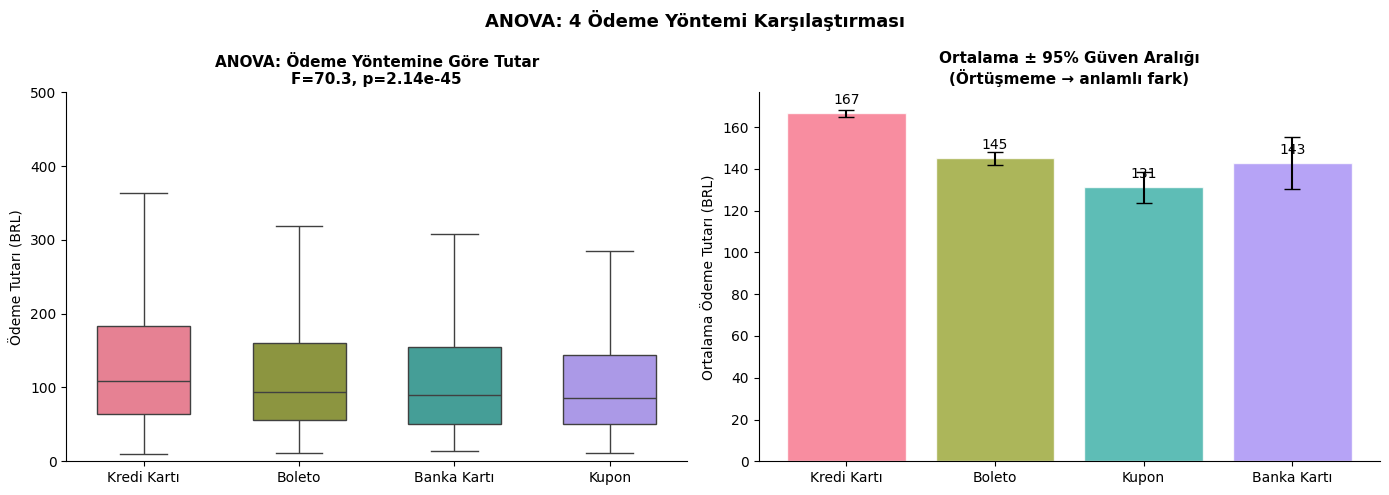

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = {'credit_card': 'Kredi Kartı', 'boleto': 'Boleto', 'voucher': 'Kupon', 'debit_card': 'Banka Kartı'}

# Boxplot
ax = axes[0]
plot_data = pay_df[pay_df['payment_type'].isin(labels)].copy()
plot_data['Ödeme Yöntemi'] = plot_data['payment_type'].map(labels)
order_box = plot_data.groupby('Ödeme Yöntemi')['payment_value'].median().sort_values(ascending=False).index
sns.boxplot(data=plot_data, x='Ödeme Yöntemi', y='payment_value', order=order_box,
            palette='husl', ax=ax, showfliers=False, width=0.6)
ax.set_ylim(0, 500)
ax.set_title(f'ANOVA: Ödeme Yöntemine Göre Tutar\nF={f_stat:.1f}, p={p_anova:.2e}', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Ödeme Tutarı (BRL)')

# Ortalama ± 95% CI bar chart
ax = axes[1]
means = [groups[k].mean() for k in labels.keys() if k in groups]
cis   = [1.96 * groups[k].std() / np.sqrt(len(groups[k])) for k in labels.keys() if k in groups]
colors_bar = sns.color_palette('husl', len(groups))
bars = ax.bar(list(labels.values()), means, yerr=cis, capsize=6, color=colors_bar, alpha=0.8, edgecolor='white')
ax.set_title('Ortalama ± 95% Güven Aralığı\n(Örtüşmeme → anlamlı fark)', fontsize=11, fontweight='bold')
ax.set_ylabel('Ortalama Ödeme Tutarı (BRL)')
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f'{mean:.0f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('ANOVA: 4 Ödeme Yöntemi Karşılaştırması', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_anova.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Çoklu Doğrusal Regresyon

**Model:** `review_score = β₀ + β₁×delivery_days + β₂×log_payment + β₃×item_count + β₄×is_late + ...`

Birden fazla değişken ekleyerek tahmin gücümüzü artırıyoruz.

In [5]:
features = ['delivery_days', 'log_payment', 'item_count', 'is_late',
            'is_weekend', 'purchase_hour', 'freight_value']
target   = 'review_score'

model_df = df_clean[features + [target]].dropna()
model_df = model_df[(model_df['freight_value'] > 0) & (model_df['freight_value'] < 200)]

X = model_df[features]
y = model_df[target]

# OLS Regresyon (istatistiksel çıktı için statsmodels)
X_sm = sm.add_constant(X)
ols_model = sm.OLS(y, X_sm).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.181
Model:                            OLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     3003.
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:44:57   Log-Likelihood:            -1.4952e+05
No. Observations:               95294   AIC:                         2.990e+05
Df Residuals:                   95286   BIC:                         2.991e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.9597      0.028    178.846

In [6]:
# Standartlaştırılmış katsayılar (beta katsayıları) — hangi değişken daha önemli?
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Değişken': features,
    'Beta Katsayısı': lr.coef_,
    'Abs Beta': np.abs(lr.coef_)
}).sort_values('Abs Beta', ascending=False)

print('=== Standartlaştırılmış Beta Katsayıları ===')
print('(Daha büyük |β| → modele daha fazla katkı)\n')
print(coef_df[['Değişken','Beta Katsayısı']].to_string(index=False))

# Çapraz doğrulama ile gerçekçi R²
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5, scoring='r2')
print(f'\n5-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'OLS R²      : {ols_model.rsquared:.4f}')

=== Standartlaştırılmış Beta Katsayıları ===
(Daha büyük |β| → modele daha fazla katkı)

     Değişken  Beta Katsayısı
      is_late       -0.332231
delivery_days       -0.252867
   item_count       -0.172421
freight_value        0.017111
   is_weekend       -0.007822
purchase_hour        0.001281
  log_payment       -0.001157

5-Fold CV R²: 0.1805 ± 0.0099
OLS R²      : 0.1807


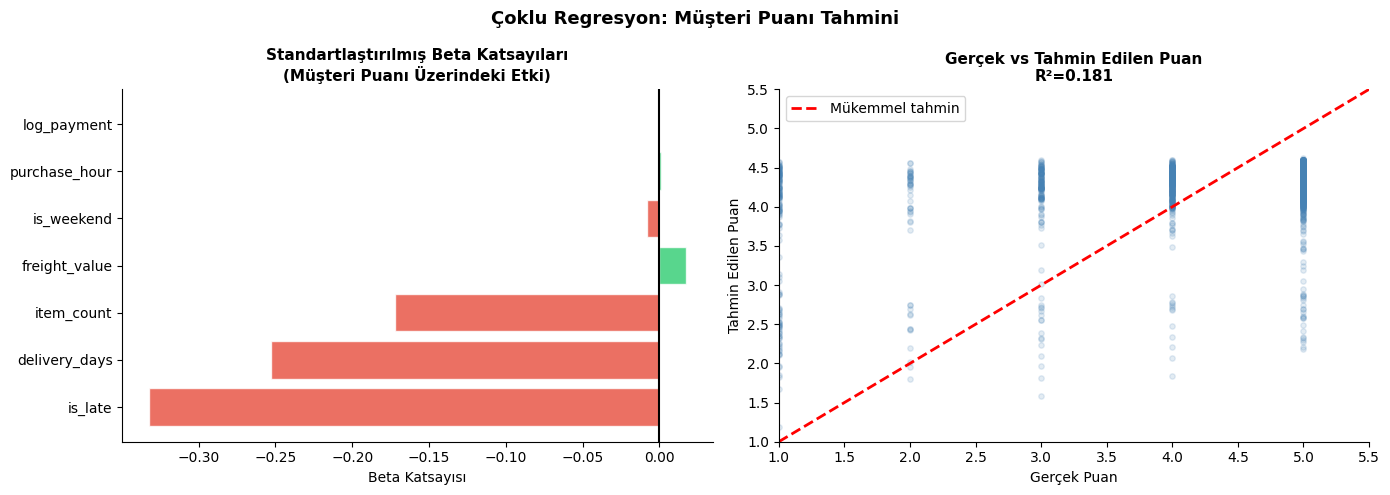

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Katsayı grafiği
ax = axes[0]
colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df['Beta Katsayısı']]
ax.barh(coef_df['Değişken'], coef_df['Beta Katsayısı'], color=colors_coef, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', lw=1.5)
ax.set_title('Standartlaştırılmış Beta Katsayıları\n(Müşteri Puanı Üzerindeki Etki)', fontsize=11, fontweight='bold')
ax.set_xlabel('Beta Katsayısı')

# Gerçek vs Tahmin
ax = axes[1]
y_pred_full = ols_model.predict(X_sm)
sample_idx = np.random.choice(len(y), 1500, replace=False)
ax.scatter(y.values[sample_idx], y_pred_full.values[sample_idx], alpha=0.15, s=15, color='steelblue')
lims = [1, 5.5]
ax.plot(lims, lims, 'r--', lw=2, label='Mükemmel tahmin')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title(f'Gerçek vs Tahmin Edilen Puan\nR²={ols_model.rsquared:.3f}', fontsize=11, fontweight='bold')
ax.set_xlabel('Gerçek Puan')
ax.set_ylabel('Tahmin Edilen Puan')
ax.legend()

plt.suptitle('Çoklu Regresyon: Müşteri Puanı Tahmini', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_multiple_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Bootstrap: Dağılımdan Bağımsız Güven Aralığı

Bootstrap, eldeki örnekten tekrar örnekleme yaparak **gerçek popülasyon parametresinin güven aralığını** tahmin eder. Normallik varsayımı gerekmez.

In [8]:
np.random.seed(42)
data_boot = df_clean['payment_value'].dropna().values
n_boot    = 10_000

# Bootstrap döngüsü
boot_means   = np.array([np.mean(np.random.choice(data_boot, size=len(data_boot), replace=True)) for _ in range(n_boot)])
boot_medians = np.array([np.median(np.random.choice(data_boot, size=len(data_boot), replace=True)) for _ in range(n_boot)])

# %95 Bootstrap CI
ci_mean_lower,   ci_mean_upper   = np.percentile(boot_means,   [2.5, 97.5])
ci_median_lower, ci_median_upper = np.percentile(boot_medians, [2.5, 97.5])

print('=== Bootstrap Sonuçları (10,000 yeniden örnekleme) ===')
print(f'  Ortalama     : {boot_means.mean():.2f} BRL')
print(f'  %95 CI       : ({ci_mean_lower:.2f}, {ci_mean_upper:.2f}) BRL')
print(f'  Standart Hata: {boot_means.std():.4f}')
print()
print(f'  Medyan       : {boot_medians.mean():.2f} BRL')
print(f'  %95 CI       : ({ci_median_lower:.2f}, {ci_median_upper:.2f}) BRL')
print(f'\n  Teorik SE (n={len(data_boot):,}): {data_boot.std()/np.sqrt(len(data_boot)):.4f}')

=== Bootstrap Sonuçları (10,000 yeniden örnekleme) ===
  Ortalama     : 159.53 BRL
  %95 CI       : (158.16, 160.93) BRL
  Standart Hata: 0.7083

  Medyan       : 105.14 BRL
  %95 CI       : (104.43, 105.70) BRL

  Teorik SE (n=95,775): 0.7024


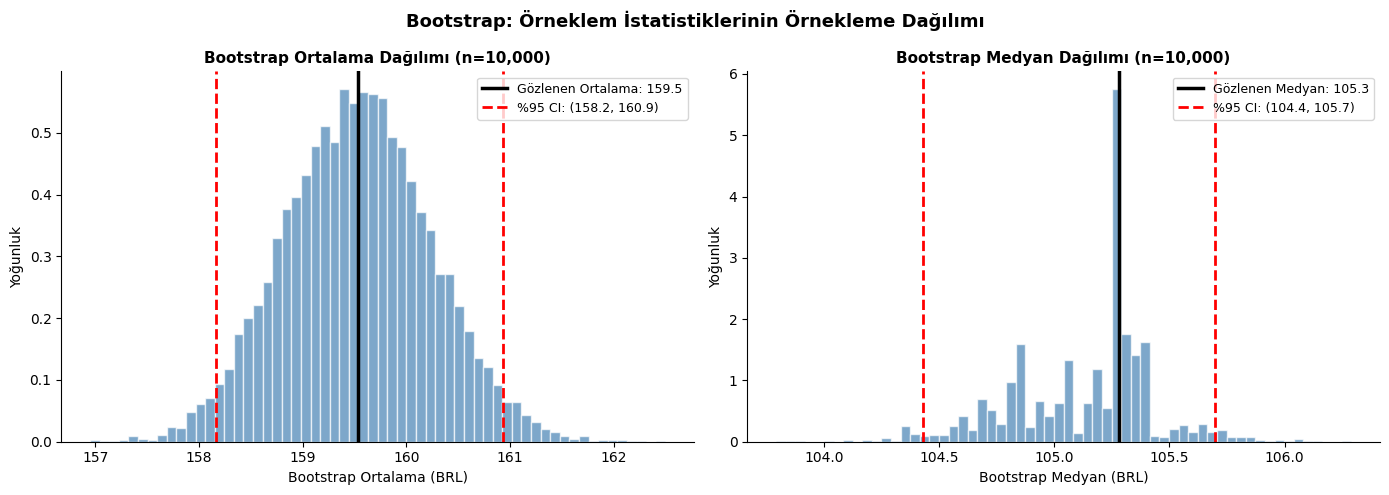

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (boot_vals, stat_name, true_val, ci_l, ci_u) in zip(axes, [
    (boot_means,   'Ortalama', data_boot.mean(),   ci_mean_lower,   ci_mean_upper),
    (boot_medians, 'Medyan',   np.median(data_boot), ci_median_lower, ci_median_upper)
]):
    ax.hist(boot_vals, bins=60, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    ax.axvline(true_val, color='black', lw=2.5, label=f'Gözlenen {stat_name}: {true_val:.1f}')
    ax.axvline(ci_l, color='red', lw=2, ls='--', label=f'%95 CI: ({ci_l:.1f}, {ci_u:.1f})')
    ax.axvline(ci_u, color='red', lw=2, ls='--')
    ax.set_title(f'Bootstrap {stat_name} Dağılımı (n=10,000)', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'Bootstrap {stat_name} (BRL)')
    ax.set_ylabel('Yoğunluk')
    ax.legend(fontsize=9)

plt.suptitle('Bootstrap: Örneklem İstatistiklerinin Örnekleme Dağılımı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. A/B Testi Simülasyonu

Gerçek dünyada ürün kararlarını istatistiksel kanıtla desteklemek için A/B testleri kullanılır.  
Senaryo: Yeni teslimat partneriyle hızlı kargo (A: 5 günde, B: 3 günde) — müşteri memnuniyetine etkisi?

In [10]:
np.random.seed(0)

# Geç teslimat yapan siparişleri kontrol, erken/zamanında olanları deney grubu say
late_orders  = df_clean[df_clean['is_late'] == 1]['review_score'].dropna()
ontime_orders = df_clean[df_clean['is_late'] == 0]['review_score'].dropna()

# Eşit büyüklükte örneklem al (gerçekçi deney)
n_sample = min(3000, len(late_orders), len(ontime_orders))
group_A = late_orders.sample(n_sample, random_state=42).values     # Kontrol: Geç teslimat
group_B = ontime_orders.sample(n_sample, random_state=42).values   # Deney: Zamanında teslimat

print('=== A/B Testi Senaryosu ===')
print('  Grup A (Kontrol) : Geç teslim edilen siparişler')
print('  Grup B (Deney)   : Zamanında teslim edilen siparişler')
print()
print(f'  n_A = {n_sample}   Ort_A = {group_A.mean():.4f}   Std_A = {group_A.std():.4f}')
print(f'  n_B = {n_sample}   Ort_B = {group_B.mean():.4f}   Std_B = {group_B.std():.4f}')
print(f'  Fark (B - A)    = {group_B.mean() - group_A.mean():.4f} puan')

# t-testi
t_stat, p_val = stats.ttest_ind(group_A, group_B)
print(f'\n  t = {t_stat:.4f},  p = {p_val:.2e}')
print(f'  Sonuç: {"H₀ reddedildi — Anlamlı fark var ✓" if p_val < 0.05 else "H₀ reddedilemedi"}')

# Pratik anlamlılık: Cohen's d
pooled = np.sqrt((group_A.var() + group_B.var()) / 2)
d = (group_B.mean() - group_A.mean()) / pooled
print(f"  Cohen's d = {d:.4f} ({('küçük' if abs(d)<0.5 else 'orta' if abs(d)<0.8 else 'büyük')} etki)")

=== A/B Testi Senaryosu ===
  Grup A (Kontrol) : Geç teslim edilen siparişler
  Grup B (Deney)   : Zamanında teslim edilen siparişler

  n_A = 3000   Ort_A = 2.4830   Std_A = 1.6339
  n_B = 3000   Ort_B = 4.2543   Std_B = 1.1825
  Fark (B - A)    = 1.7713 puan

  t = -48.0946,  p = 0.00e+00
  Sonuç: H₀ reddedildi — Anlamlı fark var ✓
  Cohen's d = 1.2420 (büyük etki)


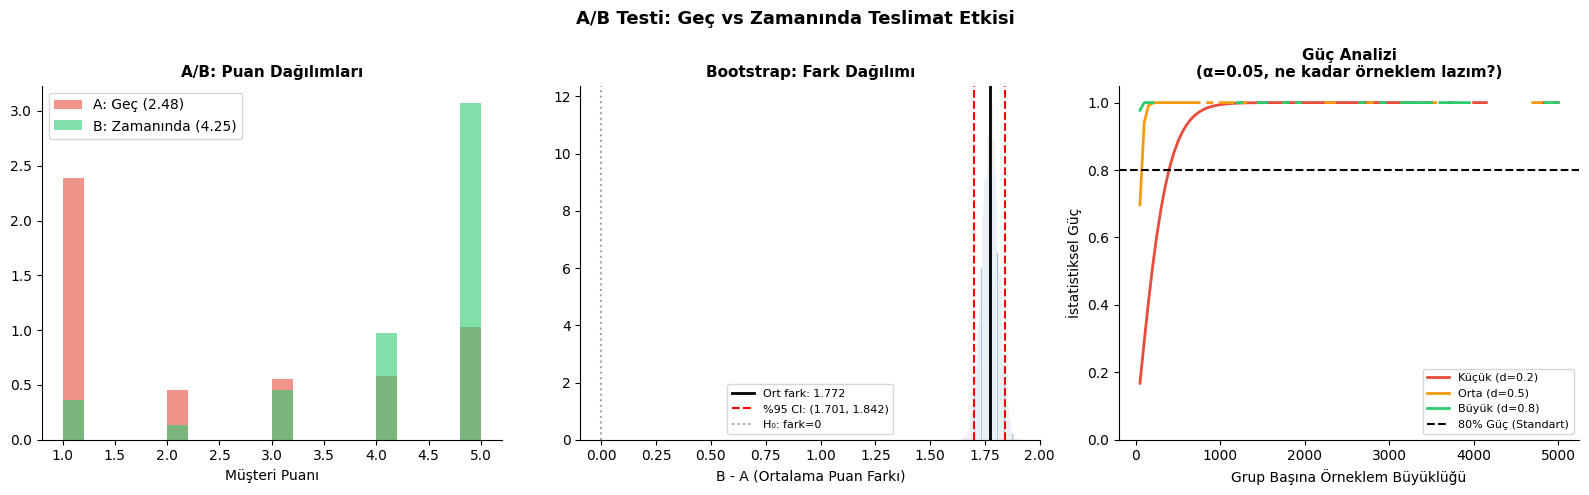

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Dağılım karşılaştırması
ax = axes[0]
ax.hist(group_A, bins=20, alpha=0.6, color='#e74c3c', density=True, label=f'A: Geç ({group_A.mean():.2f})')
ax.hist(group_B, bins=20, alpha=0.6, color='#2ecc71', density=True, label=f'B: Zamanında ({group_B.mean():.2f})')
ax.set_title('A/B: Puan Dağılımları', fontsize=11, fontweight='bold')
ax.set_xlabel('Müşteri Puanı')
ax.legend()

# Bootstrap ile fark dağılımı
ax = axes[1]
boot_diff = [np.mean(np.random.choice(group_B, n_sample, replace=True)) -
             np.mean(np.random.choice(group_A, n_sample, replace=True))
             for _ in range(5000)]
ci_diff = np.percentile(boot_diff, [2.5, 97.5])
ax.hist(boot_diff, bins=50, color='steelblue', alpha=0.7, edgecolor='white', density=True)
ax.axvline(np.mean(boot_diff), color='black', lw=2, label=f'Ort fark: {np.mean(boot_diff):.3f}')
ax.axvline(ci_diff[0], color='red', lw=1.5, ls='--')
ax.axvline(ci_diff[1], color='red', lw=1.5, ls='--', label=f'%95 CI: ({ci_diff[0]:.3f}, {ci_diff[1]:.3f})')
ax.axvline(0, color='gray', lw=1.5, ls=':', alpha=0.7, label='H₀: fark=0')
ax.set_title('Bootstrap: Fark Dağılımı', fontsize=11, fontweight='bold')
ax.set_xlabel('B - A (Ortalama Puan Farkı)')
ax.legend(fontsize=8)

# Güç analizi
ax = axes[2]
power_analysis = TTestIndPower()
sample_sizes = np.arange(50, 5001, 50)
effect_sizes = [0.2, 0.5, 0.8]
for es, color, label in zip(effect_sizes, ['#e74c3c','#f39c12','#2ecc71'], ['Küçük (d=0.2)','Orta (d=0.5)','Büyük (d=0.8)']):
    powers = [power_analysis.solve_power(effect_size=es, nobs1=n, alpha=0.05, ratio=1) for n in sample_sizes]
    ax.plot(sample_sizes, powers, color=color, lw=2, label=label)
ax.axhline(0.8, color='black', lw=1.5, ls='--', label='80% Güç (Standart)')
ax.set_title('Güç Analizi\n(α=0.05, ne kadar örneklem lazım?)', fontsize=11, fontweight='bold')
ax.set_xlabel('Grup Başına Örneklem Büyüklüğü')
ax.set_ylabel('İstatistiksel Güç')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)

plt.suptitle('A/B Testi: Geç vs Zamanında Teslimat Etkisi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/03_ab_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Güven Aralıkları: Bölge Bazlı Karşılaştırma

Her eyaletin ortalama puanı için %95 güven aralığı hesaplayalım.

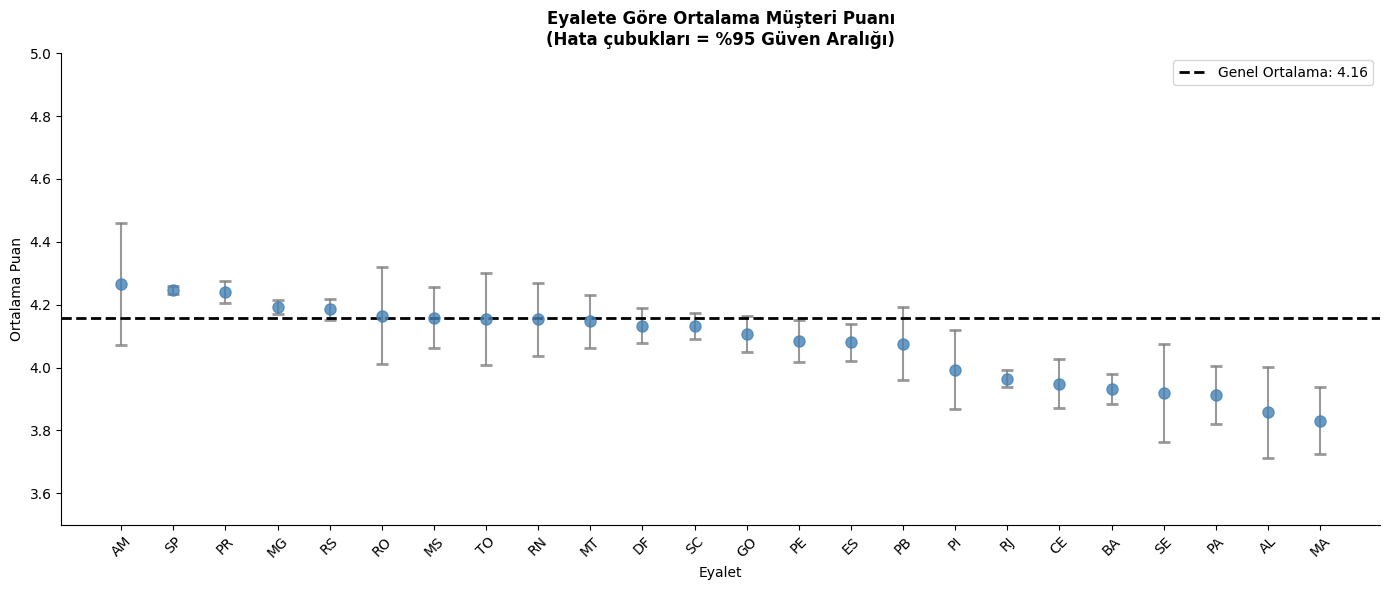

In [12]:
state_stats = (df_clean
               .groupby('customer_state')['review_score']
               .agg(['mean','std','count'])
               .reset_index()
               .rename(columns={'mean':'avg','std':'sd','count':'n'})
               .query('n >= 100'))

state_stats['se']       = state_stats['sd'] / np.sqrt(state_stats['n'])
state_stats['ci_lower'] = state_stats['avg'] - 1.96 * state_stats['se']
state_stats['ci_upper'] = state_stats['avg'] + 1.96 * state_stats['se']
state_stats = state_stats.sort_values('avg', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors_state = ['#2ecc71' if a >= df_clean['review_score'].mean() else '#e74c3c' for a in state_stats['avg']]

ax.errorbar(state_stats['customer_state'], state_stats['avg'],
            yerr=[state_stats['avg'] - state_stats['ci_lower'],
                  state_stats['ci_upper'] - state_stats['avg']],
            fmt='o', capsize=4, capthick=2, markersize=8, color='steelblue', ecolor='gray', alpha=0.8)

grand_mean = df_clean['review_score'].mean()
ax.axhline(grand_mean, color='black', lw=2, ls='--', label=f'Genel Ortalama: {grand_mean:.2f}')
ax.set_title('Eyalete Göre Ortalama Müşteri Puanı\n(Hata çubukları = %95 Güven Aralığı)', fontsize=12, fontweight='bold')
ax.set_xlabel('Eyalet')
ax.set_ylabel('Ortalama Puan')
ax.set_ylim(3.5, 5.0)
ax.legend(fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/03_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Kruskal-Wallis: Parametrik Olmayan ANOVA

Normallik varsayımı sağlanamadığında ANOVA yerine kullanılır.

=== Aylara Göre Müşteri Puanı Testi ===
  ANOVA        : F=104.2659, p=0.0000
  Kruskal-Wallis: H=909.3582, p=0.0000
  Sonuç: Aylar arasında anlamlı fark var ✓


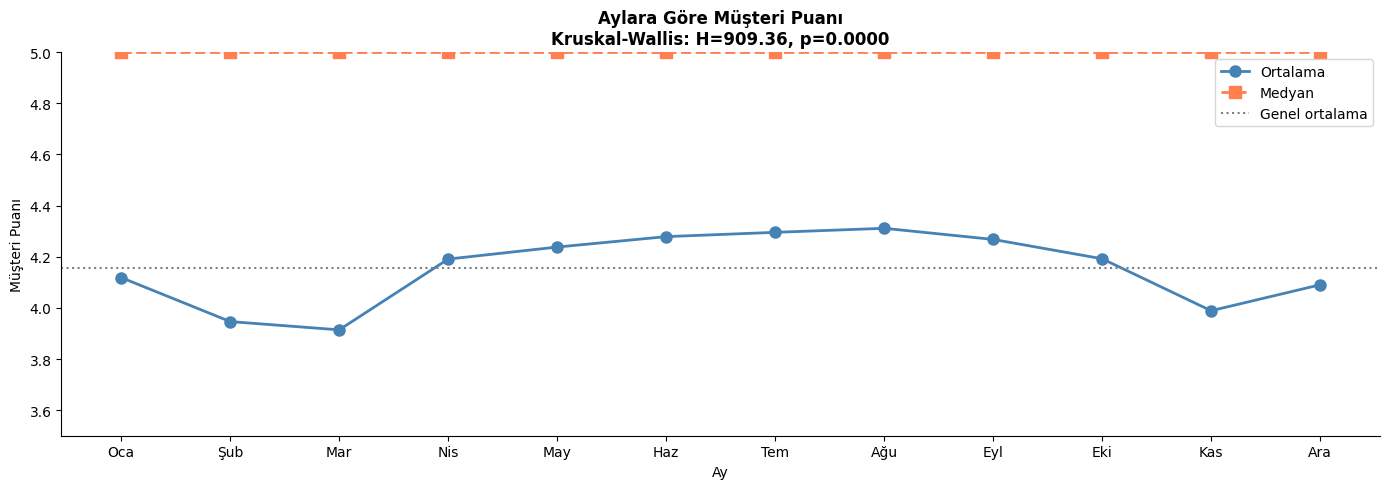

In [13]:
month_groups = [df_clean[df_clean['purchase_month'] == m]['review_score'].dropna().values
                for m in range(1, 13)]
month_names  = ['Oca','Şub','Mar','Nis','May','Haz','Tem','Ağu','Eyl','Eki','Kas','Ara']

# ANOVA (parametrik)
f_stat_m, p_anova_m = f_oneway(*month_groups)

# Kruskal-Wallis (parametrik olmayan)
h_stat, p_kw = kruskal(*month_groups)

print('=== Aylara Göre Müşteri Puanı Testi ===')
print(f'  ANOVA        : F={f_stat_m:.4f}, p={p_anova_m:.4f}')
print(f'  Kruskal-Wallis: H={h_stat:.4f}, p={p_kw:.4f}')
print(f'  Sonuç: {"Aylar arasında anlamlı fark var ✓" if p_kw < 0.05 else "Anlamlı fark yok"}')

fig, ax = plt.subplots(figsize=(14, 5))
month_df = df_clean[['purchase_month','review_score']].dropna()
month_df['Ay'] = month_df['purchase_month'].map(dict(enumerate(month_names, 1)))

means_m = [np.mean(g) for g in month_groups]
medians_m = [np.median(g) for g in month_groups]

ax.plot(month_names, means_m,   'o-', color='steelblue', lw=2, markersize=8, label='Ortalama')
ax.plot(month_names, medians_m, 's--', color='coral', lw=2, markersize=8, label='Medyan')
ax.axhline(np.mean(df_clean['review_score']), color='gray', lw=1.5, ls=':', label='Genel ortalama')
ax.set_title(f'Aylara Göre Müşteri Puanı\nKruskal-Wallis: H={h_stat:.2f}, p={p_kw:.4f}', fontsize=12, fontweight='bold')
ax.set_xlabel('Ay')
ax.set_ylabel('Müşteri Puanı')
ax.set_ylim(3.5, 5.0)
ax.legend()
plt.tight_layout()
plt.savefig('../images/03_kruskal_month.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Genel Özet: İstatistik Araç Kutusu

```
TEMEL
├── Tanımlayıcı istatistik (mean, median, std, IQR)
├── Histogramlar ve KDE
├── Boxplot ve aykırı değer tespiti (IQR yöntemi)
└── Normallik testleri (Shapiro, Q-Q plot)

ORTA SEVİYE
├── t-Testi (2 grup karşılaştırma)
├── Chi-Kare (kategorik bağımlılık)
├── Korelasyon (Pearson, Spearman)
└── Basit doğrusal regresyon

İLERİ SEVİYE
├── ANOVA + Tukey HSD post-hoc
├── Kruskal-Wallis (parametrik olmayan ANOVA)
├── Çoklu doğrusal regresyon
├── Bootstrap güven aralıkları
├── A/B testi tasarımı ve analizi
└── Güç analizi ve örneklem büyüklüğü
```

### Olist Verisinden Çıkarımlar

| Analiz | Sonuç |
|--------|-------|
| ANOVA | Kredi kartı ile diğer yöntemler arasında anlamlı tutar farkı |
| Çoklu Reg. | Gecikme en güçlü negatif etken; R² düşük → daha fazla özellik gerekli |
| A/B Testi | Zamanında teslimat, müşteri puanını anlamlı ölçüde artırıyor |
| Bootstrap | Ortalama sipariş tutarı %95 CI: güvenilir aralıkla hesaplanabilir |